In [1]:
import pandas as pd

In [2]:


df_Adipocytes_Brown = pd.read_csv('../predictions/gene_scores/gene_scores_Adipocytes_Brown_24W.csv')



In [3]:
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('AABR')]
df_Adipocytes_Brown = df_Adipocytes_Brown[~df_Adipocytes_Brown['Gene'].str.startswith('ENSRN')]

In [4]:
# Add a new column with the absolute value of the score

df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()


# Sort by absolute score

top_abs_Adipocytes_Brown = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(50)



In [5]:
top_abs_Adipocytes_Brown

,Unnamed: 0,Gene,Score,abs_score
97,97,Acaca,-3.034248,3.034248
1784,1784,Fasn,-2.669865,2.669865
1183,1183,Dst,2.415979,2.415979
4875,4875,Vcl,2.082000,2.082000
2940,2940,Mcc,-1.869162,1.869162
842,842,Clic4,1.838358,1.838358
106,106,Acly,-1.709928,1.709928
1621,1621,Eepd1,1.651003,1.651003
2260,2260,Igfbp7,1.607422,1.607422
1154,1154,Dock9,1.551066,1.551066


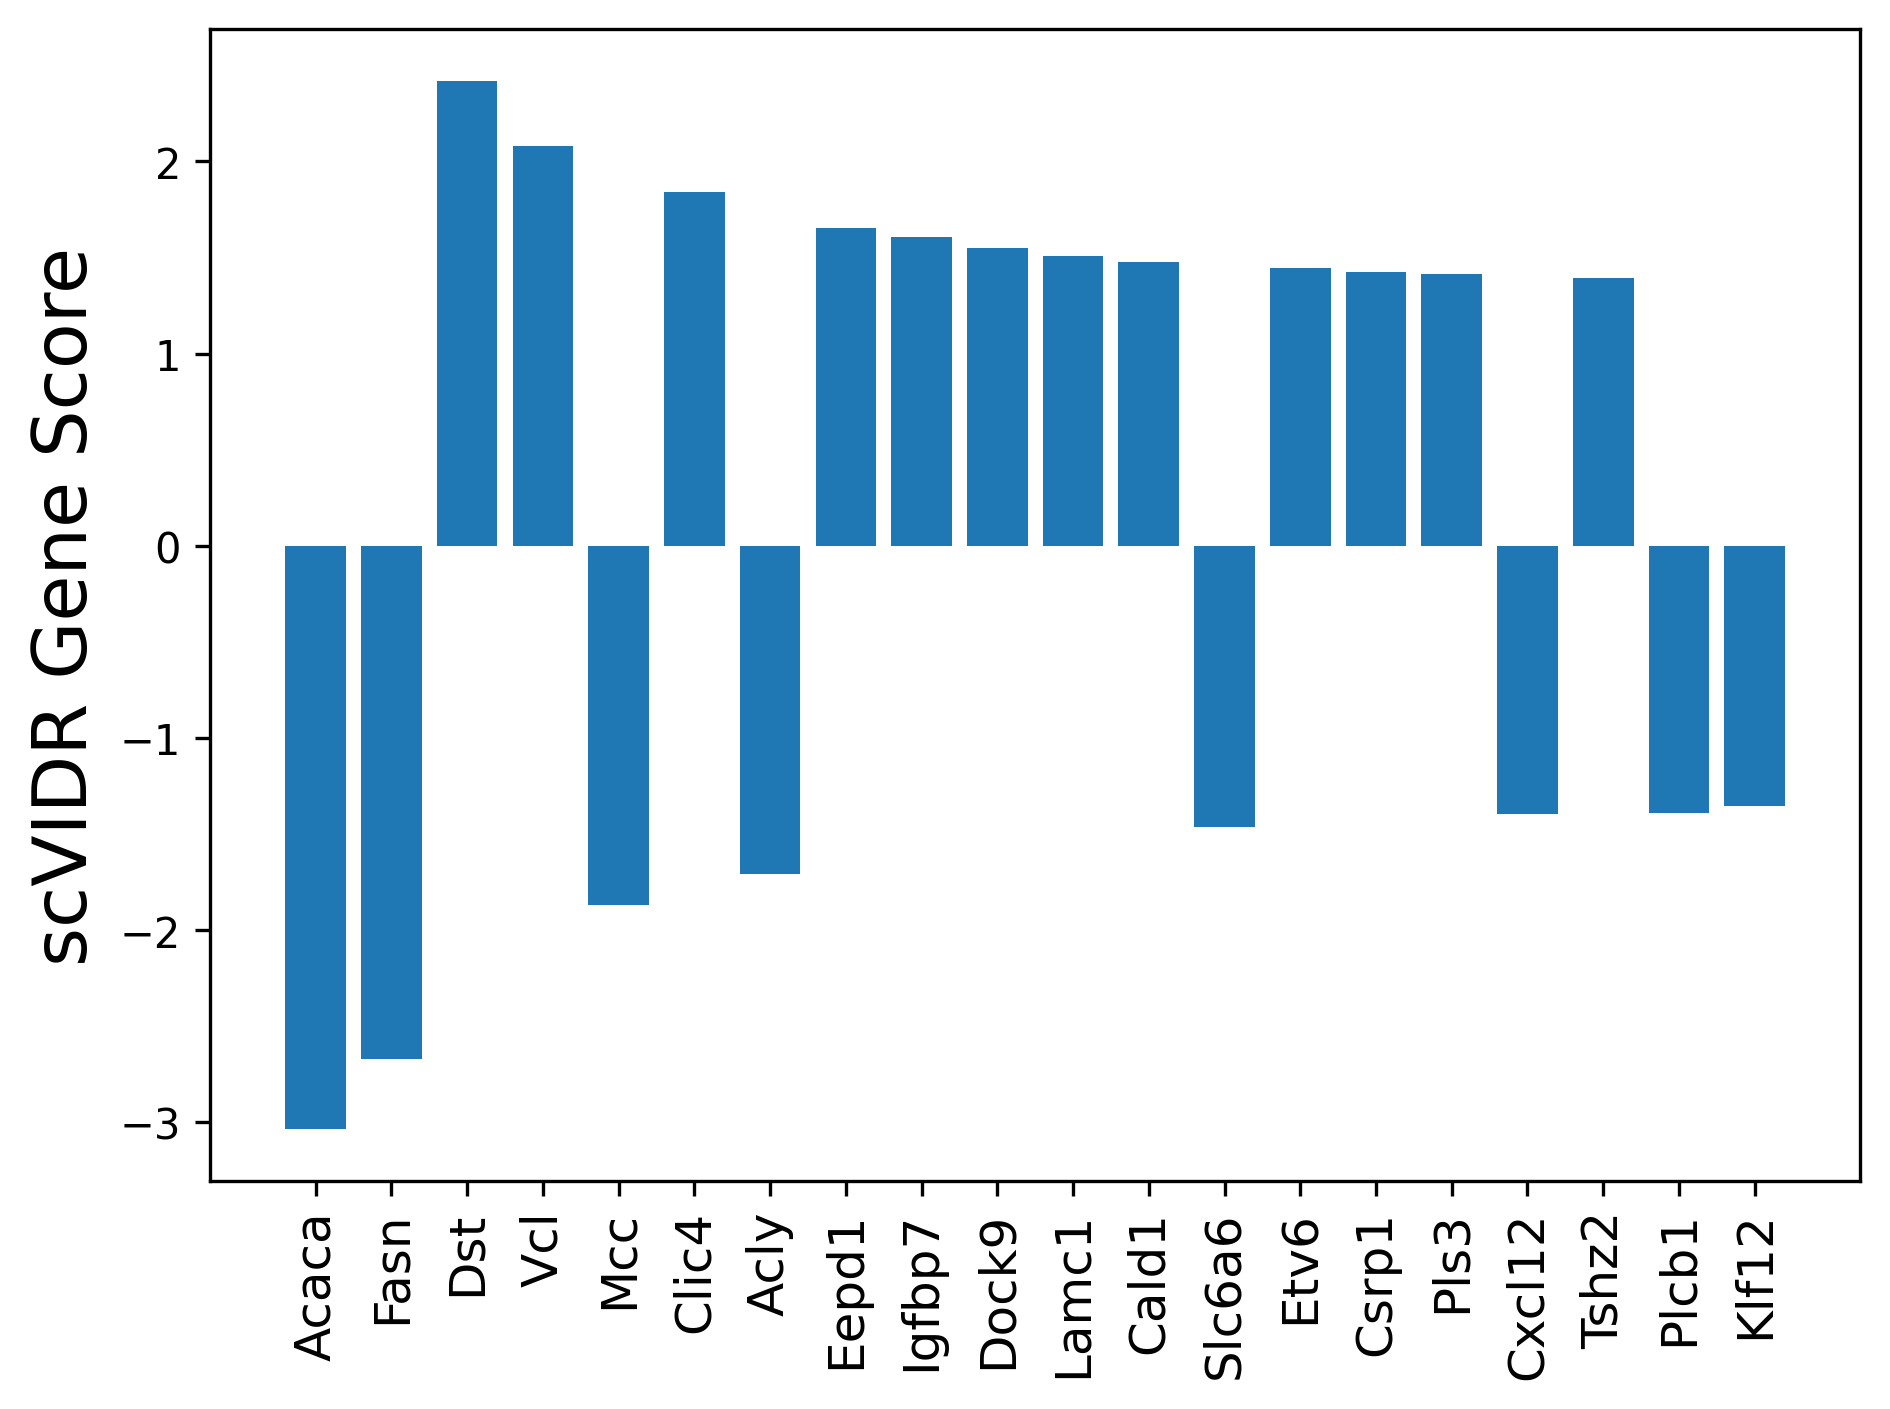

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# Sort by absolute value of score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes_df = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(20)

# Plot
plt.figure(dpi=300)
plt.bar(top_genes_df['Gene'], top_genes_df['Score'])
plt.xticks(rotation=90, fontsize=12)
plt.ylabel(r"scVIDR Gene Score", fontsize=18)
plt.tight_layout()
#plt.savefig("../figures/4A.svg", bbox_inches="tight")
plt.show()


      Unnamed: 0     Gene     Score  abs_score
1183        1183      Dst  2.415979   2.415979
4875        4875      Vcl  2.082000   2.082000
842          842    Clic4  1.838358   1.838358
1621        1621    Eepd1  1.651003   1.651003
2260        2260   Igfbp7  1.607422   1.607422
...          ...      ...       ...        ...
4444        4444    Stat3  0.503443   0.503443
4999        4999      Zyx  0.503229   0.503229
1709        1709     Etl4  0.497849   0.497849
2093        2093      Gsn  0.493741   0.493741
3457        3457  Pcdhga5  0.490181   0.490181

[100 rows x 4 columns]


/usr/local/lib/python3.9/site-packages/gseapy/enrichr.py:409: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


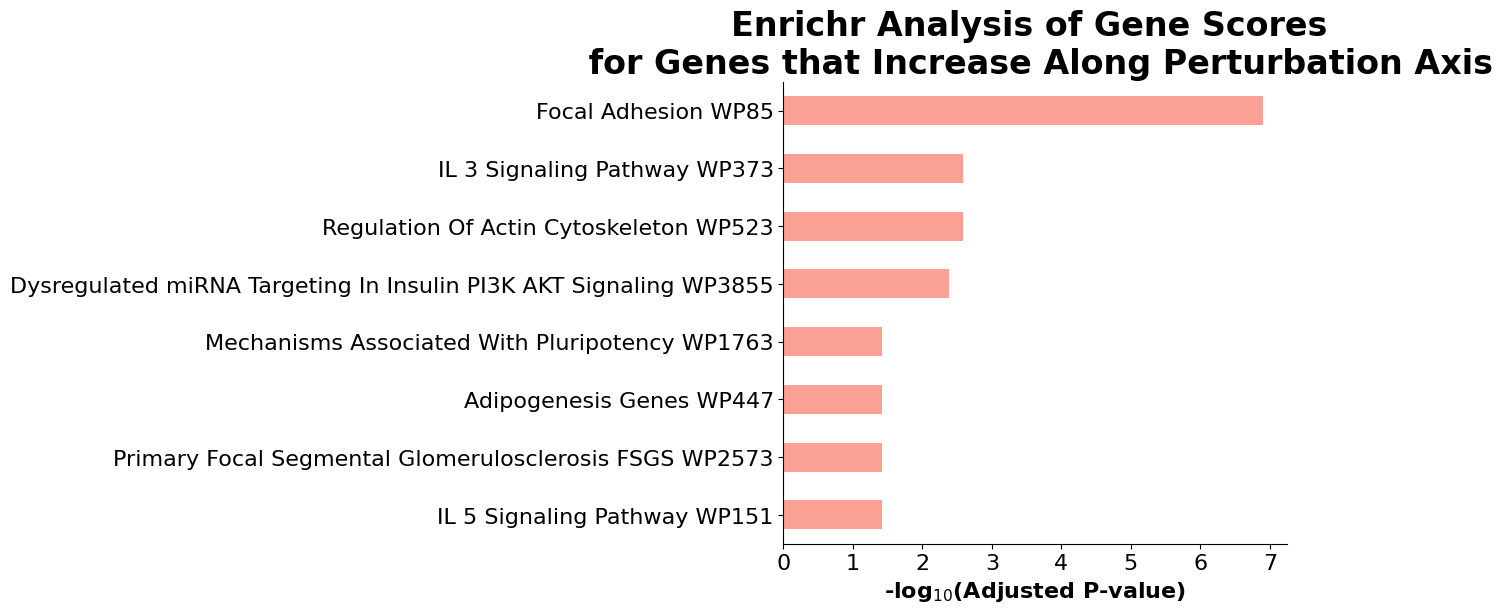

In [12]:
import gseapy as gp
import pandas as pd


# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()
top_genes = df_Adipocytes_Brown.sort_values('abs_score', ascending=False).head(100)

# Extract gene list
glist = top_genes['Gene'].tolist()

glist_top_increase = df_Adipocytes_Brown.sort_values('Score', ascending=False).head(100)

print(glist_top_increase)
glist_top_increase = glist_top_increase['Gene'].tolist()
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_increase,
    gene_sets=["WikiPathways_2024_Mouse"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)

gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Increase Along Perturbation Axis',fs = 8, top_term = 20)
#plt.savefig("../figures/4B.svg", bbox_inches = "tight")
# enr.results.head(10)

      Unnamed: 0    Gene     Score  abs_score
97            97   Acaca -3.034248   3.034248
1784        1784    Fasn -2.669865   2.669865
2940        2940     Mcc -1.869162   1.869162
106          106    Acly -1.709928   1.709928
4290        4290  Slc6a6 -1.464417   1.464417
...          ...     ...       ...        ...
4921        4921    Wif1 -0.373464   0.373464
1078        1078   Ddhd1 -0.372574   0.372574
1110        1110    Dio2 -0.372035   0.372035
4692        4692   Tmod3 -0.370965   0.370965
412          412  Bcl2l1 -0.369755   0.369755

[100 rows x 4 columns]
['Acaca', 'Fasn', 'Mcc', 'Acly', 'Slc6a6', 'Cxcl12', 'Plcb1', 'Klf12', 'Tkt', 'Fhod3', 'Ncald', 'Gpd1', 'Lmo7', 'Rasgrf2', 'St6galnac3', 'Lrrc3b', 'Heg1', 'Rgs7', 'Smad6', 'Sorbs2', 'Meox2', 'Slc26a10', 'Plxna4', 'Cyyr1', 'Gpam', 'Pnpla3', 'Scd', 'Ralgapa2', 'Nxph1', 'Phactr2', 'Septin9', 'Aspg', 'Mybpc2', 'Akr1c15', 'Pde4d', 'Cdk14', 'Slc35f1', 'Plpp3', 'Adgrf5', 'Tmcc3', 'Mxi1', 'Runx1t1', 'Slc27a1', 'Gmpr', 'Eng', 'Ph

/usr/local/lib/python3.9/site-packages/gseapy/enrichr.py:409: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  self.results = self.results.append(res, ignore_index=True)


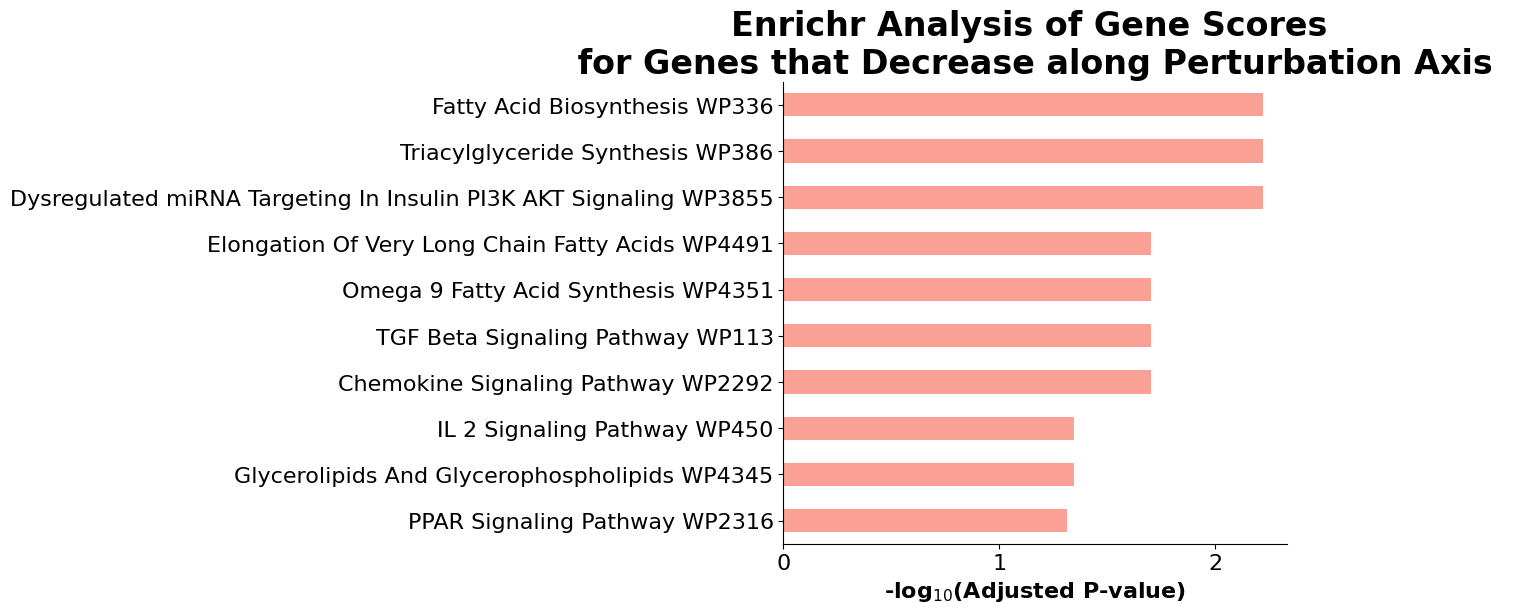

In [11]:
import gseapy as gp
import pandas as pd



# Rank by absolute score
df_Adipocytes_Brown['abs_score'] = df_Adipocytes_Brown['Score'].abs()

glist_top_decrease = df_Adipocytes_Brown.sort_values('Score', ascending=True).head(100)
print(glist_top_decrease)
glist_top_decrease = glist_top_decrease['Gene'].tolist()

print(glist_top_decrease)
# Enrichment analysis
enr = gp.enrichr(
    gene_list=glist_top_decrease,
    gene_sets=["WikiPathways_2024_Mouse"], #["GO_Biological_Process_2023"],
    organism='Mouse',
    #description='adipocytes_brown_top100',
    #outdir='results/enrichr_adipocytes_brown',
    cutoff=0.5  # relaxed cutoff
)

gp.plot.barplot(enr.results,title='Enrichr Analysis of Gene Scores \n for Genes that Decrease along Perturbation Axis ',fs = 8, top_term = 20)

